In [38]:
from scipy.io import loadmat

# Exploring File Structure 
data = loadmat('../data/train.mat')

print([k for k in data.keys() if not k.startswith('__')])

['trainData', 'trainLabels']


In [39]:
train_data = data['trainData']
train_labels = data['trainLabels']

print(f"trainData: {train_data.shape, train_data.dtype}")
print(f"trainLabels: {train_labels.shape, train_labels.dtype}")

trainData: ((393, 5000), dtype('<f8'))
trainLabels: ((393, 1), dtype('O'))


In [40]:
# observe first 5 labels to clarify type
print(f"First 5 labels: {train_labels[:5]}")

# find type of just one label object
print(f"Type of first label: {type(train_labels[0,0])}")

First 5 labels: [[array(['InnerRaceFault'], dtype='<U14')]
 [array(['InnerRaceFault'], dtype='<U14')]
 [array(['InnerRaceFault'], dtype='<U14')]
 [array(['InnerRaceFault'], dtype='<U14')]
 [array(['InnerRaceFault'], dtype='<U14')]]
Type of first label: <class 'numpy.ndarray'>


The train.mat dataset has 393 examples. 

There are 5000 float64 features per example, each representing what the sensor caputed at a certain time. 

In [41]:
# capture unwrapped element
unwrapped_label = train_labels[0,0][0]
print(f"Label: {unwrapped_label}")

# capture type of unwrapped element type
print(f"Label Type: {type(unwrapped_label[0])}")

Label: InnerRaceFault
Label Type: <class 'str'>


The Label is a String representing what (if any) kind of fault there is

In [42]:
import numpy as np

# flatten labels of training data
labels_flat_train = np.array([label[0] for label in train_labels.ravel()])

# check class distribution
unique_classes, counts = np.unique(labels_flat_train, return_counts=True)

for cls, cnt in zip(unique_classes, counts):
    print(f"{cls}: {cnt} samples")

InnerRaceFault: 131 samples
Normal: 131 samples
OuterRaceFault: 131 samples


All classes are balanced, with 131 examples for each.

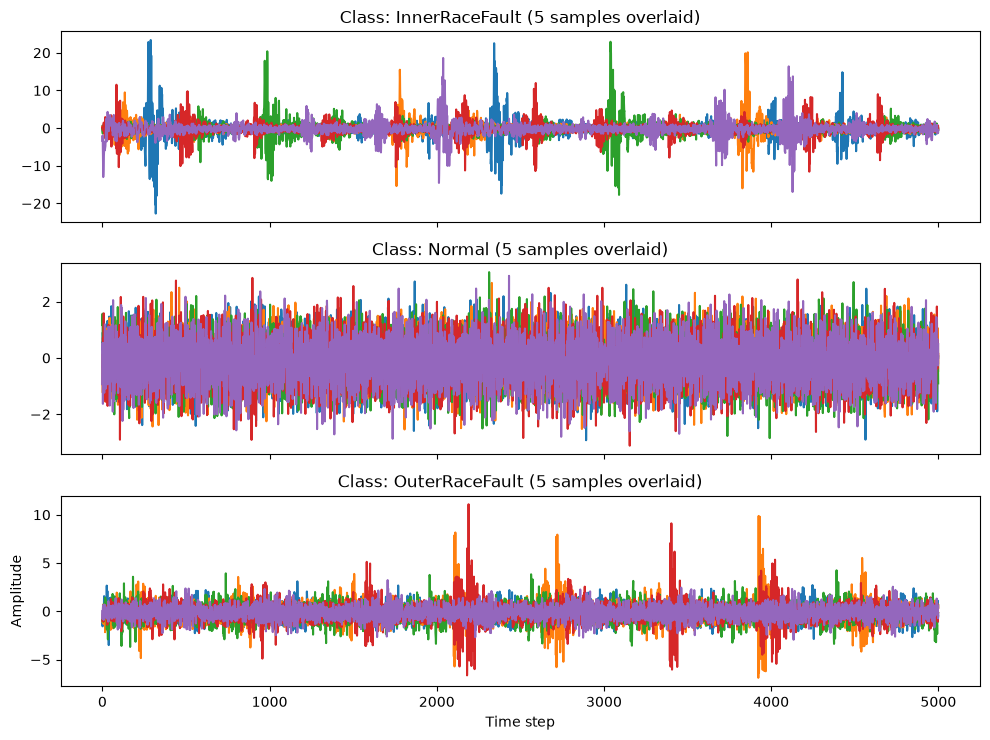

In [43]:
import matplotlib.pyplot as plt 

# plot 5 samples per class, overlaid
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(10, 2.5 * len(unique_classes)), sharex=True)

for ax, cls in zip(axes, unique_classes):
    inds = np.where(labels_flat_train == cls)[0][:5]
    for ind in inds:
        ax.plot(train_data[ind])
    ax.set_title(f"Class: {cls} (5 samples overlaid)")


axes[-1].set_xlabel("Time step")
axes[-1].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()


# Analysis:

* InnerRaceFault: Periodic sharp spikes reaching +20 to -20.
* Normal: Dense, consistently noise signal. No distinct spikes, and varying steadily within a smaller range of +2 and -2.
* OuterRaceFault: Periodic spikes reaching smaller magnitudes than InnerRaceFault (increasing by at most 10 and decreasing by at most 5 from base level).

The classes are distinguishable to the human eye. This suggests that the model should be able to seperate these classes reasonably well.
Features like peak amplitude and spike frequency/spacing could be very effective for training the model.
    

In [44]:
# basic stats per class

for cls in unique_classes:
    inds = np.where(labels_flat_train  == cls)[0]
    cls_data = train_data[inds]
    print(f"{cls}: \n"
          f"Mean: {cls_data.mean():.4f}, Standard deviation: {cls_data.std():.4f}, Min:{cls_data.min():.4f}, Max: {cls_data.max():.4f}\n")

InnerRaceFault: 
Mean: -0.2148, Standard deviation: 1.8874, Min:-45.9739, Max: 39.3167

Normal: 
Mean: -0.1034, Standard deviation: 0.7705, Min:-3.7484, Max: 3.6498

OuterRaceFault: 
Mean: -0.1432, Standard deviation: 0.8986, Min:-19.4333, Max: 16.2188



In [45]:
# basic checks for class balance in test dataset

data = loadmat('../data/test.mat')

test_data = data['testData']
test_labels = data['testLabels']

print(f"testData: {test_data.shape, test_data.dtype}")
print(f"testLabels: {test_labels.shape, test_labels.dtype}")

labels_flat_test = np.array([label[0] for label in test_labels.ravel()])
unique_classes_test, counts_test = np.unique(labels_flat_test, return_counts=True)

for cls, cnt in zip(unique_classes_test, counts_test):
    print(f"{cls}: {cnt} samples")

testData: ((102, 5000), dtype('<f8'))
testLabels: ((102, 1), dtype('O'))
InnerRaceFault: 34 samples
Normal: 34 samples
OuterRaceFault: 34 samples


In [46]:
# basic checks for class balance in val dataset
data = loadmat('../data/val.mat')

val_data = data['valData']
val_labels = data['valLabels']

print("Val:")
print(f"valData: {val_data.shape, val_data.dtype}")
print(f"valLabels: {val_labels.shape, val_labels.dtype}")

labels_flat_val = np.array([label[0] for label in val_labels.ravel()])
unique_classes_val, counts_val = np.unique(labels_flat_val, return_counts=True)

for cls, cnt in zip(unique_classes_val, counts_val):
    print(f"{cls}: {cnt} samples")

Val:
valData: ((27, 5000), dtype('<f8'))
valLabels: ((27, 1), dtype('O'))
InnerRaceFault: 9 samples
Normal: 9 samples
OuterRaceFault: 9 samples


There is a balanced class distribution for Val and Test datasets. They both have the same amount of features as the train dataset, verifying cleanliness.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)

# fits based on train_data to prevent data leakage and make sure data is scaled uniformly
test_data_scaled = scaler.transform(test_data)
val_data_scaled = scaler.transform(val_data)